Cell 1: Install and import libraries

In [ ]:
!pip -q install torchsummary

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, Subset
from torchsummary import summary

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import random
import time
import copy

Cell 2: Set random seed and device

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: Tesla T4


Cell 3: Load CIFAR-10 with train/validation/test split

In [ ]:
batch_size = 128

# CIFAR-10 normalization values
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Load CIFAR-10
train_full_aug = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

train_full_clean = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=test_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

# Create consistent train/validation split
num_train = len(train_full_aug)
indices = np.arange(num_train)
np.random.seed(SEED)
np.random.shuffle(indices)

train_size = 45000
val_size = 5000

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(train_full_aug, train_indices)
val_dataset = Subset(train_full_clean, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

classes = test_dataset.classes

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))
print("Classes:", classes)

100%|██████████| 170M/170M [00:03<00:00, 44.5MB/s]


Training samples: 45000
Validation samples: 5000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Cell 4: Define Modified AlexNet for CIFAR-10

Part A

In [ ]:
class ModifiedAlexNet(nn.Module):
    def __init__(self, dropout_p=0.0):
        super(ModifiedAlexNet, self).__init__()

        self.features = nn.Sequential(
            # Input: 3 x 32 x 32
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),   # 64 x 32 x 32
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),                  # 64 x 16 x 16

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), # 128 x 16 x 16
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),                  # 128 x 8 x 8

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),# 256 x 8 x 8
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),# 256 x 8 x 8
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),# 128 x 8 x 8
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)                   # 128 x 4 x 4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),

            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Cell 5: Check model summary and parameter count

In [ ]:
baseline_model = ModifiedAlexNet(dropout_p=0.0).to(device)

summary(baseline_model, input_size=(3, 32, 32))

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

baseline_params = count_parameters(baseline_model)
original_alexnet_params = 61000000

print("Modified AlexNet trainable parameters:", baseline_params)
print("Original AlexNet approximate parameters:", original_alexnet_params)
print("Modified model is about", round(original_alexnet_params / baseline_params, 2), "times smaller")

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 128, 16, 16]          73,856
              ReLU-5          [-1, 128, 16, 16]               0
         MaxPool2d-6            [-1, 128, 8, 8]               0
            Conv2d-7            [-1, 256, 8, 8]         295,168
              ReLU-8            [-1, 256, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         590,080
             ReLU-10            [-1, 256, 8, 8]               0
           Conv2d-11            [-1, 128, 8, 8]         295,040
             ReLU-12            [-1, 128, 8, 8]               0
        MaxPool2d-13            [-1, 128, 4, 4]               0
          Flatten-14                 [-

Cell 6: Training and evaluation functions

In [ ]:
def train_one_model(model, train_loader, val_loader, epochs=30, lr=0.001, weight_decay=0.0):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        scheduler.step()

        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = 100 * correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Val Loss: {val_loss:.4f} "
            f"Val Acc: {val_acc:.2f}%"
        )

    total_time = time.time() - start_time
    print("Training complete.")
    print("Best validation accuracy:", best_val_acc)
    print("Training time in minutes:", total_time / 60)

    model.load_state_dict(best_model_wts)

    return model, history, best_val_acc

Cell 7: Train Part A baseline model

In [ ]:
epochs = 30
learning_rate = 0.001
weight_decay = 0.0

baseline_model = ModifiedAlexNet(dropout_p=0.0).to(device)

baseline_model, baseline_history, baseline_best_val_acc = train_one_model(
    baseline_model,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay
)

Epoch [1/30] Train Loss: 1.7680 Val Loss: 1.4414 Val Acc: 45.74%
Epoch [2/30] Train Loss: 1.3185 Val Loss: 1.2487 Val Acc: 55.40%
Epoch [3/30] Train Loss: 1.0840 Val Loss: 0.9836 Val Acc: 65.16%
Epoch [4/30] Train Loss: 0.9215 Val Loss: 0.9113 Val Acc: 67.44%
Epoch [5/30] Train Loss: 0.8031 Val Loss: 0.8545 Val Acc: 70.86%
Epoch [6/30] Train Loss: 0.7309 Val Loss: 0.6922 Val Acc: 76.64%
Epoch [7/30] Train Loss: 0.6635 Val Loss: 0.6923 Val Acc: 76.22%
Epoch [8/30] Train Loss: 0.6163 Val Loss: 0.6416 Val Acc: 78.56%
Epoch [9/30] Train Loss: 0.5738 Val Loss: 0.5991 Val Acc: 79.64%
Epoch [10/30] Train Loss: 0.5334 Val Loss: 0.5749 Val Acc: 80.38%
Epoch [11/30] Train Loss: 0.5001 Val Loss: 0.5891 Val Acc: 80.02%
Epoch [12/30] Train Loss: 0.4732 Val Loss: 0.5680 Val Acc: 81.22%
Epoch [13/30] Train Loss: 0.4364 Val Loss: 0.5284 Val Acc: 82.92%
Epoch [14/30] Train Loss: 0.4123 Val Loss: 0.5569 Val Acc: 81.68%
Epoch [15/30] Train Loss: 0.3916 Val Loss: 0.5533 Val Acc: 82.14%
Epoch [16/30] Train

Cell 8: Plot Part A training curves

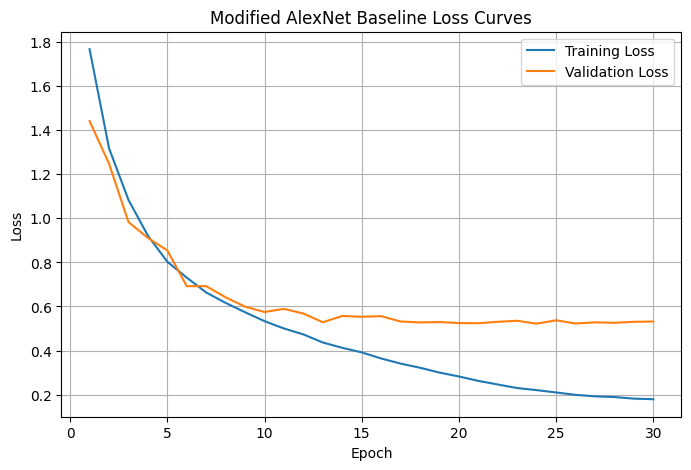

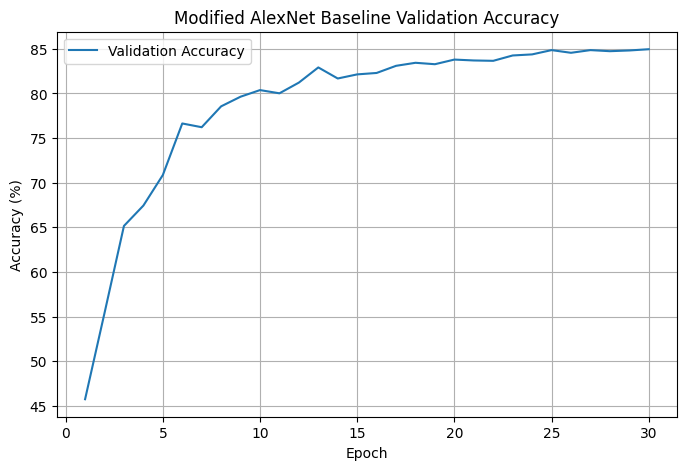

In [9]:
def plot_single_history(history, title):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], label="Training Loss")
    plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(title + " Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_single_history(baseline_history, "Modified AlexNet Baseline")

Cell 9: Test accuracy function

In [10]:
def evaluate_on_test(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = 100 * correct / total

    return test_acc, np.array(all_labels), np.array(all_preds)

In [11]:
baseline_test_acc, baseline_labels, baseline_preds = evaluate_on_test(
    baseline_model,
    test_loader
)

print("Baseline test accuracy:", baseline_test_acc)

Baseline test accuracy: 85.24


Cell 10: Confusion matrix for baseline model

<Figure size 1000x800 with 0 Axes>

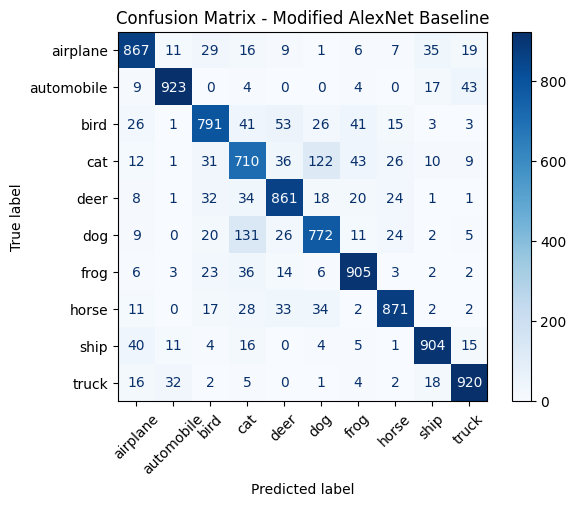

In [12]:
cm = confusion_matrix(baseline_labels, baseline_preds)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix - Modified AlexNet Baseline")
plt.show()

Cell 11: Visualize first convolutional layer filters

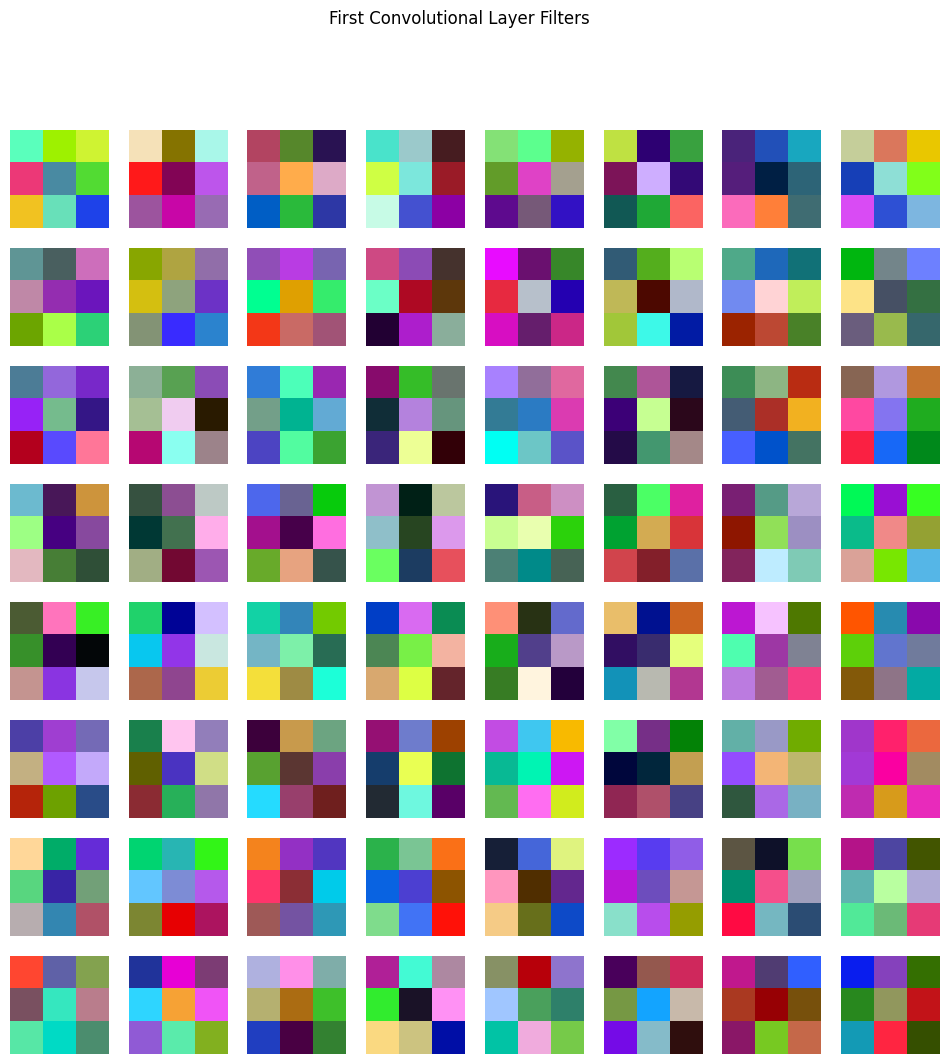

In [13]:
def visualize_first_layer_filters(model):
    first_conv = model.features[0]
    filters = first_conv.weight.data.cpu().clone()

    num_filters = filters.shape[0]

    plt.figure(figsize=(12, 12))

    for i in range(min(num_filters, 64)):
        filt = filters[i]

        # Convert from C x H x W to H x W x C
        filt = filt.permute(1, 2, 0)

        # Normalize for display
        filt_min = filt.min()
        filt_max = filt.max()
        filt = (filt - filt_min) / (filt_max - filt_min + 1e-8)

        plt.subplot(8, 8, i + 1)
        plt.imshow(filt)
        plt.axis("off")

    plt.suptitle("First Convolutional Layer Filters")
    plt.show()

visualize_first_layer_filters(baseline_model)

Cell 12: Train dropout model with p = 0.3

Part B

In [14]:
dropout03_model = ModifiedAlexNet(dropout_p=0.3).to(device)

dropout03_model, dropout03_history, dropout03_best_val_acc = train_one_model(
    dropout03_model,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay
)

Epoch [1/30] Train Loss: 1.7893 Val Loss: 1.4300 Val Acc: 46.18%
Epoch [2/30] Train Loss: 1.3542 Val Loss: 1.1765 Val Acc: 57.02%
Epoch [3/30] Train Loss: 1.1311 Val Loss: 0.9628 Val Acc: 65.36%
Epoch [4/30] Train Loss: 0.9917 Val Loss: 0.9090 Val Acc: 67.86%
Epoch [5/30] Train Loss: 0.8735 Val Loss: 0.7752 Val Acc: 72.50%
Epoch [6/30] Train Loss: 0.8008 Val Loss: 0.7768 Val Acc: 72.48%
Epoch [7/30] Train Loss: 0.7390 Val Loss: 0.7164 Val Acc: 74.46%
Epoch [8/30] Train Loss: 0.6800 Val Loss: 0.6866 Val Acc: 76.30%
Epoch [9/30] Train Loss: 0.6371 Val Loss: 0.6721 Val Acc: 77.74%
Epoch [10/30] Train Loss: 0.5975 Val Loss: 0.6245 Val Acc: 78.98%
Epoch [11/30] Train Loss: 0.5610 Val Loss: 0.6077 Val Acc: 78.82%
Epoch [12/30] Train Loss: 0.5278 Val Loss: 0.5924 Val Acc: 79.48%
Epoch [13/30] Train Loss: 0.5062 Val Loss: 0.5540 Val Acc: 81.28%
Epoch [14/30] Train Loss: 0.4748 Val Loss: 0.5531 Val Acc: 81.10%
Epoch [15/30] Train Loss: 0.4535 Val Loss: 0.5699 Val Acc: 81.46%
Epoch [16/30] Train

In [15]:
dropout03_test_acc, dropout03_labels, dropout03_preds = evaluate_on_test(
    dropout03_model,
    test_loader
)

print("Dropout p=0.3 test accuracy:", dropout03_test_acc)

Dropout p=0.3 test accuracy: 84.76


Cell 13: Train dropout model with p = 0.5

In [16]:
dropout05_model = ModifiedAlexNet(dropout_p=0.5).to(device)

dropout05_model, dropout05_history, dropout05_best_val_acc = train_one_model(
    dropout05_model,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=weight_decay
)

Epoch [1/30] Train Loss: 1.8596 Val Loss: 1.5780 Val Acc: 39.58%
Epoch [2/30] Train Loss: 1.4823 Val Loss: 1.3677 Val Acc: 50.52%
Epoch [3/30] Train Loss: 1.2738 Val Loss: 1.1422 Val Acc: 58.56%
Epoch [4/30] Train Loss: 1.1222 Val Loss: 1.0421 Val Acc: 61.48%
Epoch [5/30] Train Loss: 1.0232 Val Loss: 0.9413 Val Acc: 66.42%
Epoch [6/30] Train Loss: 0.9448 Val Loss: 0.8762 Val Acc: 68.88%
Epoch [7/30] Train Loss: 0.8804 Val Loss: 0.8027 Val Acc: 71.02%
Epoch [8/30] Train Loss: 0.8218 Val Loss: 0.7617 Val Acc: 73.42%
Epoch [9/30] Train Loss: 0.7727 Val Loss: 0.7285 Val Acc: 74.46%
Epoch [10/30] Train Loss: 0.7311 Val Loss: 0.7108 Val Acc: 75.44%
Epoch [11/30] Train Loss: 0.6850 Val Loss: 0.7049 Val Acc: 76.24%
Epoch [12/30] Train Loss: 0.6517 Val Loss: 0.6650 Val Acc: 78.04%
Epoch [13/30] Train Loss: 0.6225 Val Loss: 0.6631 Val Acc: 77.40%
Epoch [14/30] Train Loss: 0.5906 Val Loss: 0.6432 Val Acc: 78.94%
Epoch [15/30] Train Loss: 0.5732 Val Loss: 0.6075 Val Acc: 80.22%
Epoch [16/30] Train

In [17]:
dropout05_test_acc, dropout05_labels, dropout05_preds = evaluate_on_test(
    dropout05_model,
    test_loader
)

print("Dropout p=0.5 test accuracy:", dropout05_test_acc)

Dropout p=0.5 test accuracy: 83.26


Cell 14: Compare baseline and dropout curves

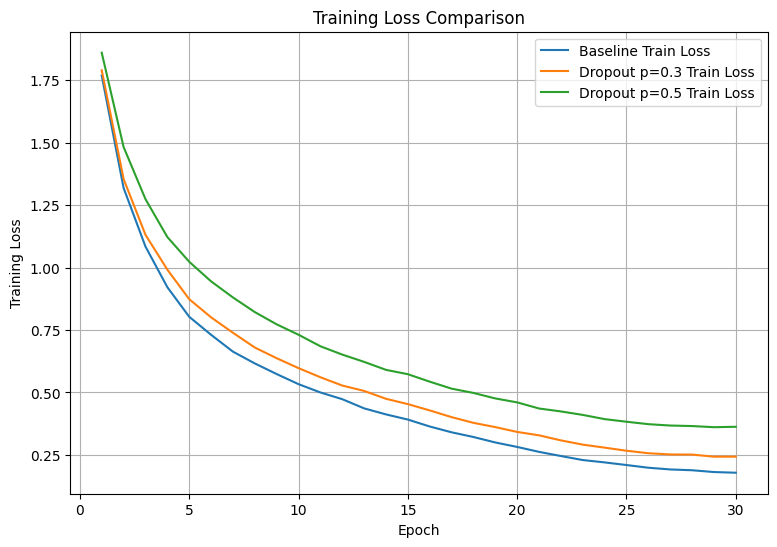

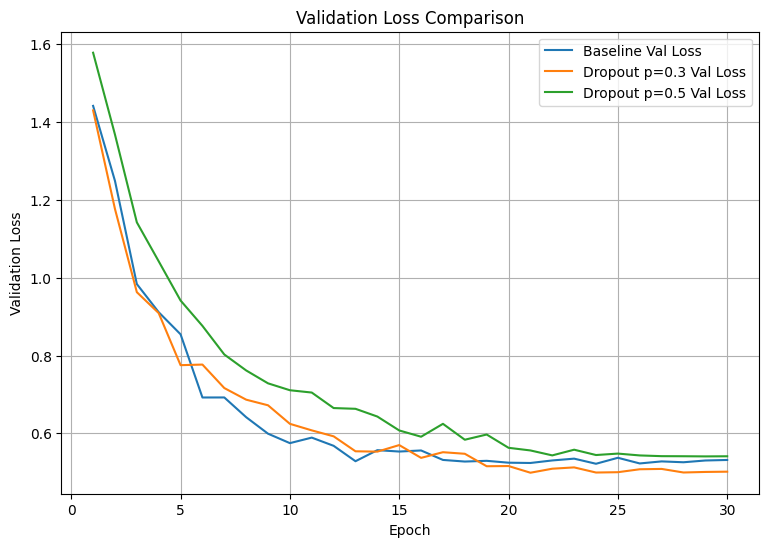

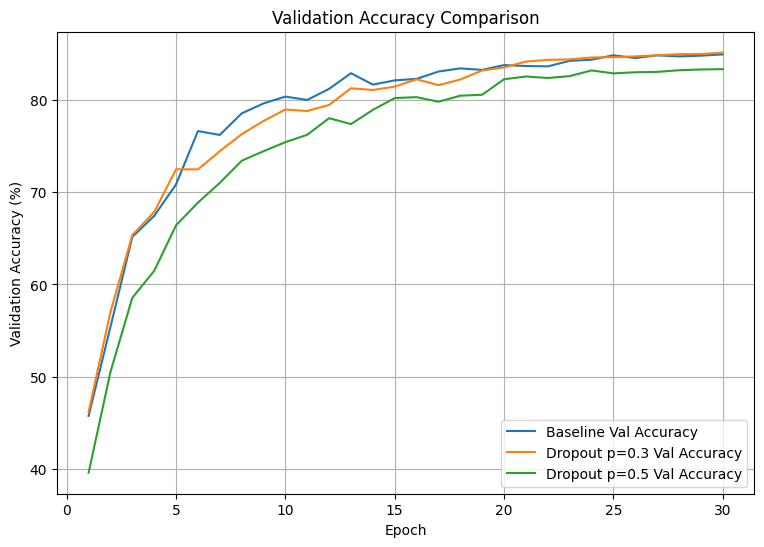

In [18]:
def compare_histories(histories, labels):
    epochs_range = range(1, len(histories[0]["train_loss"]) + 1)

    plt.figure(figsize=(9, 6))
    for history, label in zip(histories, labels):
        plt.plot(epochs_range, history["train_loss"], label=f"{label} Train Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Training Loss")
    plt.title("Training Loss Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(9, 6))
    for history, label in zip(histories, labels):
        plt.plot(epochs_range, history["val_loss"], label=f"{label} Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("Validation Loss Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(9, 6))
    for history, label in zip(histories, labels):
        plt.plot(epochs_range, history["val_acc"], label=f"{label} Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy (%)")
    plt.title("Validation Accuracy Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

compare_histories(
    [baseline_history, dropout03_history, dropout05_history],
    ["Baseline", "Dropout p=0.3", "Dropout p=0.5"]
)

Cell 15: Results table

In [19]:
results = {
    "Model": [
        "Baseline, no dropout",
        "Dropout p=0.3",
        "Dropout p=0.5"
    ],
    "Best Validation Accuracy (%)": [
        baseline_best_val_acc,
        dropout03_best_val_acc,
        dropout05_best_val_acc
    ],
    "Test Accuracy (%)": [
        baseline_test_acc,
        dropout03_test_acc,
        dropout05_test_acc
    ],
    "Parameters": [
        count_parameters(baseline_model),
        count_parameters(dropout03_model),
        count_parameters(dropout05_model)
    ]
}

import pandas as pd

results_df = pd.DataFrame(results)
results_df

,Model,Best Validation Accuracy (%),Test Accuracy (%),Parameters
0,"Baseline, no dropout",84.96,85.24,2438922
1,Dropout p=0.3,85.14,84.76,2438922
2,Dropout p=0.5,83.36,83.26,2438922


Cell 16: Bonus model with L2 weight decay

In [20]:
l2_model = ModifiedAlexNet(dropout_p=0.0).to(device)

l2_model, l2_history, l2_best_val_acc = train_one_model(
    l2_model,
    train_loader,
    val_loader,
    epochs=epochs,
    lr=learning_rate,
    weight_decay=1e-4
)

Epoch [1/30] Train Loss: 1.7611 Val Loss: 1.4994 Val Acc: 44.36%
Epoch [2/30] Train Loss: 1.3440 Val Loss: 1.1905 Val Acc: 57.12%
Epoch [3/30] Train Loss: 1.1456 Val Loss: 1.0160 Val Acc: 63.30%
Epoch [4/30] Train Loss: 0.9932 Val Loss: 0.9568 Val Acc: 66.18%
Epoch [5/30] Train Loss: 0.8795 Val Loss: 0.8104 Val Acc: 71.04%
Epoch [6/30] Train Loss: 0.7938 Val Loss: 0.7432 Val Acc: 73.50%
Epoch [7/30] Train Loss: 0.7294 Val Loss: 0.6983 Val Acc: 75.90%
Epoch [8/30] Train Loss: 0.6748 Val Loss: 0.6866 Val Acc: 76.98%
Epoch [9/30] Train Loss: 0.6324 Val Loss: 0.6317 Val Acc: 77.86%
Epoch [10/30] Train Loss: 0.5859 Val Loss: 0.6093 Val Acc: 80.10%
Epoch [11/30] Train Loss: 0.5492 Val Loss: 0.5593 Val Acc: 80.78%
Epoch [12/30] Train Loss: 0.5189 Val Loss: 0.5635 Val Acc: 81.00%
Epoch [13/30] Train Loss: 0.4937 Val Loss: 0.5441 Val Acc: 81.80%
Epoch [14/30] Train Loss: 0.4612 Val Loss: 0.5338 Val Acc: 81.98%
Epoch [15/30] Train Loss: 0.4368 Val Loss: 0.5162 Val Acc: 82.80%
Epoch [16/30] Train

In [21]:
l2_test_acc, l2_labels, l2_preds = evaluate_on_test(
    l2_model,
    test_loader
)

print("L2 weight decay test accuracy:", l2_test_acc)

L2 weight decay test accuracy: 84.66


In [22]:
bonus_results = {
    "Model": [
        "Baseline, no dropout",
        "Dropout p=0.3",
        "Dropout p=0.5",
        "L2 weight decay = 1e-4"
    ],
    "Best Validation Accuracy (%)": [
        baseline_best_val_acc,
        dropout03_best_val_acc,
        dropout05_best_val_acc,
        l2_best_val_acc
    ],
    "Test Accuracy (%)": [
        baseline_test_acc,
        dropout03_test_acc,
        dropout05_test_acc,
        l2_test_acc
    ]
}

bonus_results_df = pd.DataFrame(bonus_results)
bonus_results_df

,Model,Best Validation Accuracy (%),Test Accuracy (%)
0,"Baseline, no dropout",84.96,85.24
1,Dropout p=0.3,85.14,84.76
2,Dropout p=0.5,83.36,83.26
3,L2 weight decay = 1e-4,86.06,84.66


End of Problem 1